In [1]:
import os
import sys

import keras
import tensorflow as tf
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

sys.path.insert(0, "../../packages/python")
from data import plots as plots

2025-07-19 13:31:50.062247: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-19 13:31:50.068652: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752942710.075850   74258 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752942710.078208   74258 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752942710.084081   74258 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
#Configure TensorFlow to use the specified GPUs
gpus = tf.config.list_physical_devices('GPU')
print("GPU Available:", gpus)
print("cuDNN Enabled:", tf.test.is_built_with_cuda())

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
cuDNN Enabled: True


In [3]:
sys.path.insert(0, "../../")
from config import DATASETS_PATH

# Load Dataset
VALIDATION_PATH = os.path.join(DATASETS_PATH, 'mitosis_classification', 'valid')
TEST_PATH = os.path.join(DATASETS_PATH, 'mitosis_classification', 'test')

#Load model
EXPERIMENT_NAME = 'cell-mitosis-classifier-training'
MODEL_NAME = 'mitosis_classifier'
MODEL_PATH = f'../../experiments/{EXPERIMENT_NAME}/outputs/{MODEL_NAME}.keras'


In [4]:
def create_and_preprocess_generator(path, shuffle=True):
    generator = tf.keras.utils.image_dataset_from_directory(
        path,
        labels="inferred",
        label_mode="categorical",
        batch_size=32,
        image_size=(128, 128),
        color_mode='grayscale',
        shuffle=shuffle,
        seed=42 # Mantener la semilla para reproducibilidad
    )
    generator = generator.map(
        lambda x, y: (x / 255.0, y),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    generator = generator.prefetch(buffer_size=tf.data.AUTOTUNE)
    return generator

In [5]:
validation_generator = create_and_preprocess_generator(VALIDATION_PATH, shuffle=False) # No es necesario shuffear la validación

# El test set no necesita shuffe y puede cargarse solo una vez si la función se usa para retornar todo
test_generator = create_and_preprocess_generator(TEST_PATH, shuffle=False)

Found 3488 files belonging to 2 classes.
Found 1764 files belonging to 2 classes.


I0000 00:00:1752942711.416949   74258 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21400 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6


In [6]:
model = keras.models.load_model(MODEL_PATH)
plots.plot_conf_matrix(model, validation_generator, 'valid' + ' - image')

2025-07-19 13:31:52.057235: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


ValueError: Input 0 of layer "functional" is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(32, 128, 128)

----------------------------------------
ACCURACY: 0.9019274376417233
RECALL: 0.8231046931407943
PRECISION: 0.8587570621468926
SPECIFICITY: 0.9380165289256198
----------------------------------------




2025-07-18 10:34:33.132521: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


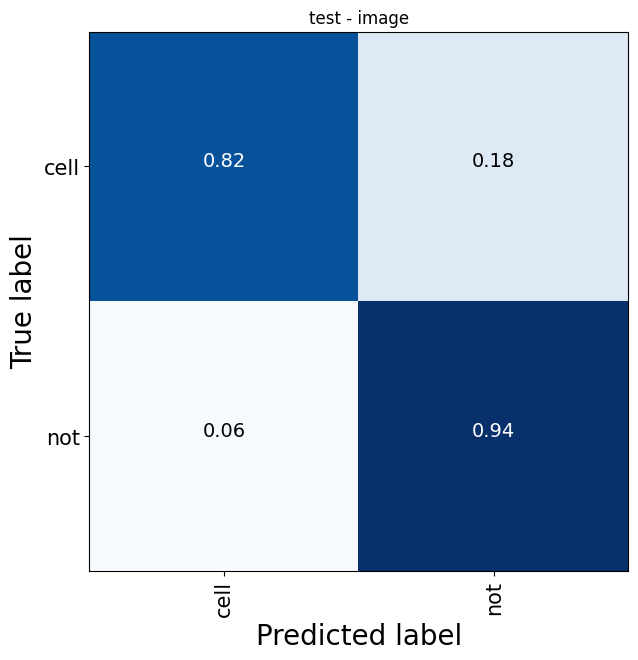

In [ ]:
plots.plot_conf_matrix(model, test_generator, 'test' + ' - image')